<a href="https://colab.research.google.com/github/sidneyppratt-svg/credit-spread-monitor/blob/main/mortgage_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance pandas numpy matplotlib -q
print("Libraries ready")

Libraries ready


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import datetime
import warnings
warnings.filterwarnings('ignore')

print("Imports complete")

Imports complete


In [ ]:
START = "2010-01-01"
END   = datetime.date.today().strftime("%Y-%m-%d")

print(f"Date range: {START} to {END}")

Date range: 2010-01-01 to 2026-09-21


In [ ]:
print("Downloading data...")

# 10-Year Treasury Yield — the benchmark mortgage rates are priced off
tnx = yf.download("^TNX", start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
tnx.name = "10Y_Treasury"

# 30-Year Treasury Yield — long-end reference rate
tyx = yf.download("^TYX", start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
tyx.name = "30Y_Treasury"

# MBB — iShares MBS ETF — tracks agency mortgage-backed securities
mbb = yf.download("MBB", start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
mbb.name = "MBB"

# AGG — Investment Grade Bond ETF — benchmark comparison for MBS
agg = yf.download("AGG", start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
agg.name = "AGG"

# Combine into one DataFrame
df = pd.concat([tnx, tyx, mbb, agg], axis=1).dropna()
df.columns = ["10Y_Treasury", "30Y_Treasury", "MBB", "AGG"]

print(f"Downloaded {len(df)} trading days of data")
print(f"Date range: {df.index[0].strftime('%b %d, %Y')} to {df.index[-1].strftime('%b %d, %Y')}")
print(df.tail(3).round(2))

Downloaded 4201 trading days of data
Date range: Jan 04, 2010 to Sep 18, 2026
            10Y_Treasury  30Y_Treasury    MBB    AGG
Date                                                
2026-09-16          5.01          5.35  91.23  95.81
2026-09-17          4.95          5.30  91.81  96.33
2026-09-18          5.00          5.33  91.29  95.96


In [ ]:
# MBB vs AGG relative return — captures dynamic spread widening/tightening
# When MBB underperforms AGG, investors are demanding more yield from MBS
mbb_returns = df["MBB"].pct_change().rolling(21).mean()
agg_returns = df["AGG"].pct_change().rolling(21).mean()
mbs_vs_agg  = (agg_returns - mbb_returns) * 10000  # convert to basis points

# Approximate 30-year mortgage rate
# Base spread of 1.75% = long-run historical average mortgage spread
# Stress adjustment captures dynamic widening/tightening from MBB vs AGG
base_spread = 1.75
stress_adj  = mbs_vs_agg.clip(-1, 2) / 100
df["Mortgage_Rate_Approx"] = df["10Y_Treasury"] + base_spread + stress_adj

# Mortgage spread = approximate mortgage rate minus 10-year Treasury
df["Mortgage_Spread"] = df["Mortgage_Rate_Approx"] - df["10Y_Treasury"]
df["Spread_Smooth"]   = df["Mortgage_Spread"].rolling(21).mean()

df = df.dropna()

print(f"Current approx 30Y mortgage rate: {df['Mortgage_Rate_Approx'].iloc[-1]:.2f}%")
print(f"Current mortgage spread:          {df['Mortgage_Spread'].iloc[-1]:.2f}%  ({df['Mortgage_Spread'].iloc[-1]*100:.0f} bps)")
print(f"Historical average spread (2010): {df['Mortgage_Spread'].mean():.2f}%")

Current approx 30Y mortgage rate: 6.77%
Current mortgage spread:          1.77%  (177 bps)
Historical average spread (2010): 1.75%


In [ ]:
def classify_spread(spread):
    if spread < 1.50:   return "TIGHT"
    elif spread < 2.00: return "NORMAL"
    elif spread < 2.50: return "WIDE"
    else:               return "VERY WIDE"

def classify_refi(mortgage_rate, rate_12m_ago):
    if pd.isna(rate_12m_ago): return "UNKNOWN"
    drop = rate_12m_ago - mortgage_rate
    if drop >= 1.50:   return "REFI WAVE"
    elif drop >= 0.75: return "ACTIVE REFI"
    elif drop >= 0.25: return "SOME REFI"
    else:              return "MINIMAL REFI"

def prepayment_risk(spread_regime, refi_env):
    if refi_env in ["REFI WAVE", "ACTIVE REFI"]: return "HIGH"
    elif refi_env == "SOME REFI":                return "MODERATE"
    elif spread_regime == "TIGHT":               return "MODERATE"
    else:                                        return "LOW"

# Apply classifications to every row
df["Spread_Regime"] = df["Mortgage_Spread"].apply(classify_spread)

rate_12m = df["Mortgage_Rate_Approx"].shift(252)
df["Refi_Signal"] = [
    classify_refi(row["Mortgage_Rate_Approx"], rate_12m.iloc[i])
    for i, (_, row) in enumerate(df.iterrows())
]

df["Prepay_Risk"] = [
    prepayment_risk(row["Spread_Regime"], row["Refi_Signal"])
    for _, row in df.iterrows()
]

print("Regime classification complete")
print(f"Current spread regime:     {df['Spread_Regime'].iloc[-1]}")
print(f"Current refi environment:  {df['Refi_Signal'].iloc[-1]}")
print(f"Current prepayment risk:   {df['Prepay_Risk'].iloc[-1]}")

Regime classification complete
Current spread regime:     NORMAL
Current refi environment:  MINIMAL REFI
Current prepayment risk:   LOW


In [ ]:
cur_10y    = float(df["10Y_Treasury"].iloc[-1])
cur_30y    = float(df["30Y_Treasury"].iloc[-1])
cur_mort   = float(df["Mortgage_Rate_Approx"].iloc[-1])
cur_spread = float(df["Mortgage_Spread"].iloc[-1])
cur_regime = df["Spread_Regime"].iloc[-1]
cur_refi   = df["Refi_Signal"].iloc[-1]
cur_prepay = df["Prepay_Risk"].iloc[-1]
cur_date   = df.index[-1].strftime("%B %d, %Y")
avg_spread = float(df["Mortgage_Spread"].mean())
pct_rank   = float((df["Mortgage_Spread"] < cur_spread).mean() * 100)
spread_52w_high = float(df["Mortgage_Spread"].tail(252).max())
spread_52w_low  = float(df["Mortgage_Spread"].tail(252).min())
mbb_1m  = float((df["MBB"].iloc[-1] / df["MBB"].iloc[-21]  - 1) * 100)
mbb_12m = float((df["MBB"].iloc[-1] / df["MBB"].iloc[-252] - 1) * 100)

print("=" * 60)
print(f"MORTGAGE MARKET MONITOR — {cur_date}")
print("=" * 60)
print(f"")
print(f"10-Year Treasury Yield:      {cur_10y:.2f}%")
print(f"30-Year Treasury Yield:      {cur_30y:.2f}%")
print(f"Approx 30Y Mortgage Rate:    {cur_mort:.2f}%")
print(f"Mortgage Spread (vs 10Y):    {cur_spread:.2f}%  ({cur_spread*100:.0f} bps)")
print(f"Spread Percentile (2010):    {pct_rank:.0f}th percentile")
print(f"52-Week High Spread:         {spread_52w_high:.2f}%")
print(f"52-Week Low Spread:          {spread_52w_low:.2f}%")
print(f"")
print(f"Spread Regime:               {cur_regime}")
print(f"Refinancing Environment:     {cur_refi}")
print(f"Prepayment Risk:             {cur_prepay}")
print(f"")
print(f"MBB (MBS ETF) 1-Month:       {mbb_1m:+.1f}%")
print(f"MBB (MBS ETF) 12-Month:      {mbb_12m:+.1f}%")

MORTGAGE MARKET MONITOR — September 18, 2026

10-Year Treasury Yield:      5.00%
30-Year Treasury Yield:      5.33%
Approx 30Y Mortgage Rate:    6.77%
Mortgage Spread (vs 10Y):    1.77%  (177 bps)
Spread Percentile (2010):    85th percentile
52-Week High Spread:         1.77%
52-Week Low Spread:          1.74%

Spread Regime:               NORMAL
Refinancing Environment:     MINIMAL REFI
Prepayment Risk:             LOW

MBB (MBS ETF) 1-Month:       -1.8%
MBB (MBS ETF) 12-Month:      +0.2%


In [ ]:
interps = {
    "TIGHT": (
        "The mortgage spread is tighter than normal. Lenders are comfortable "
        "and competition for mortgage origination is high. MBS are rich relative "
        "to Treasuries — investors receiving less compensation than historical "
        "averages. Positive for existing MBS holders. Less attractive for new purchases."
    ),
    "NORMAL": (
        "The mortgage spread is in the normal historical range. Lenders are "
        "pricing mortgage risk appropriately relative to Treasury yields. "
        "MBS are fairly valued. Normal prepayment modeling assumptions apply. "
        "The spread at the 85th percentile suggests conditions are on the "
        "wider end of NORMAL — worth monitoring for further widening."
    ),
    "WIDE": (
        "The mortgage spread is wider than normal. Lenders are demanding more "
        "compensation above Treasury yields — reflecting elevated prepayment "
        "uncertainty or broader fixed income stress. MBS are cheap relative to "
        "Treasuries. Wide spreads can represent a buying opportunity if the "
        "widening is technical rather than fundamental."
    ),
    "VERY WIDE": (
        "The mortgage spread is at historically elevated levels. Significant "
        "stress in the MBS market. This level has occurred during severe crises "
        "such as 2008-09 and the COVID shock in March 2020. MBS are very cheap "
        "relative to Treasuries. Intensive analysis required before acting."
    ),
}

refi_interps = {
    "REFI WAVE": (
        "Mortgage rates have fallen significantly from 12 months ago. A large "
        "portion of existing mortgages are in the money to refinance. Prepayment "
        "acceleration is significant — MBS holders receive principal back faster "
        "than expected, sharply shortening duration."
    ),
    "ACTIVE REFI": (
        "Mortgage rates have fallen meaningfully. Refinancing activity is elevated "
        "and prepayment speeds are above normal. MBS with higher coupons are being "
        "called away — duration is shorter than nominal maturity suggests."
    ),
    "SOME REFI": (
        "Some refinancing activity but not a wave. Prepayment speeds are modestly "
        "above baseline. Borrowers well in the money may refinance opportunistically."
    ),
    "MINIMAL REFI": (
        "Current rates are not materially below a year ago. Most borrowers have "
        "little incentive to refinance. Prepayment speeds are near baseline CPR "
        "(Conditional Prepayment Rate). MBS duration is closer to its stated maturity."
    ),
    "UNKNOWN": "Insufficient history to classify the refinancing environment.",
}

print(f"SPREAD REGIME: {cur_regime}")
print("─" * 50)
print(interps.get(cur_regime, ""))
print()
print(f"REFINANCING ENVIRONMENT: {cur_refi}")
print("─" * 50)
print(refi_interps.get(cur_refi, ""))

SPREAD REGIME: NORMAL
──────────────────────────────────────────────────
The mortgage spread is in the normal historical range. Lenders are pricing mortgage risk appropriately relative to Treasury yields. MBS are fairly valued. Normal prepayment modeling assumptions apply. The spread at the 85th percentile suggests conditions are on the wider end of NORMAL — worth monitoring for further widening.

REFINANCING ENVIRONMENT: MINIMAL REFI
──────────────────────────────────────────────────
Current rates are not materially below a year ago. Most borrowers have little incentive to refinance. Prepayment speeds are near baseline CPR (Conditional Prepayment Rate). MBS duration is closer to its stated maturity.


In [ ]:
watches = {
    "TIGHT": [
        "Watch for spread widening — market stress widens mortgage spreads quickly from tight levels",
        "Monitor the Fed — rate hikes push mortgage rates up and slow origination",
        "Watch housing data — existing home sales and new construction affect origination volume",
        "Tight spreads leave little cushion — any volatility spike can cause rapid widening",
    ],
    "NORMAL": [
        "Watch the 10-year yield — at 5.00% any further rise pushes mortgage rates toward 7%+ and further slows housing",
        "Monitor Fed communications — any pivot toward cuts would steepen the curve and compress the mortgage spread",
        "Watch weekly MBA mortgage application data — a leading indicator of prepayment trends",
        "Track MBB vs AGG relative performance daily — MBB is already down 1.8% this month, watch for acceleration",
        "The 85th percentile spread reading means conditions are on the wide end of NORMAL — one more widening move hits WIDE",
    ],
    "WIDE": [
        "Watch for spread compression — if stress resolves, wide spreads can rally sharply",
        "Determine the source of widening — technical selling or fundamental deterioration?",
        "Track bank appetite for MBS — banks buying or selling directly affects spreads",
        "Watch for Fed MBS purchase programs — Fed buying narrows spreads significantly",
    ],
    "VERY WIDE": [
        "Monitor for Fed intervention — Fed has stepped in at extreme spread levels historically",
        "Watch for forced selling from leveraged MBS holders — can cause spreads to overshoot fair value",
        "Track SOFR spreads — banking system stress correlates with extreme MBS spread widening",
        "Watch for convexity hedging flows — rapid rate moves force MBS hedgers to sell Treasuries",
    ],
}

print(f"WHAT TO WATCH — {cur_regime} REGIME")
print("─" * 50)
for w in watches.get(cur_regime, []):
    print(f"→ {w}")

WHAT TO WATCH — NORMAL REGIME
──────────────────────────────────────────────────
→ Watch the 10-year yield — at 5.00% any further rise pushes mortgage rates toward 7%+ and further slows housing
→ Monitor Fed communications — any pivot toward cuts would steepen the curve and compress the mortgage spread
→ Watch weekly MBA mortgage application data — a leading indicator of prepayment trends
→ Track MBB vs AGG relative performance daily — MBB is already down 1.8% this month, watch for acceleration
→ The 85th percentile spread reading means conditions are on the wide end of NORMAL — one more widening move hits WIDE


In [ ]:
print("HISTORICAL CONTEXT")
print("─" * 50)
print(f"Average Mortgage Spread since 2010:  {avg_spread:.2f}%")
print(f"Current Spread vs Average:           {cur_spread - avg_spread:+.2f}%")
print(f"52-Week High Spread:                 {spread_52w_high:.2f}%")
print(f"52-Week Low Spread:                  {spread_52w_low:.2f}%")
print(f"Current Percentile since 2010:       {pct_rank:.0f}th")
print()

regime_dist = df["Spread_Regime"].value_counts(normalize=True) * 100
print("Spread Regime Distribution (since 2010):")
for regime in ["TIGHT", "NORMAL", "WIDE", "VERY WIDE"]:
    pct = regime_dist.get(regime, 0)
    bar = "█" * int(pct / 2)
    print(f"  {regime:<12} {pct:5.1f}%  {bar}")

HISTORICAL CONTEXT
──────────────────────────────────────────────────
Average Mortgage Spread since 2010:  1.75%
Current Spread vs Average:           +0.02%
52-Week High Spread:                 1.77%
52-Week Low Spread:                  1.74%
Current Percentile since 2010:       85th

Spread Regime Distribution (since 2010):
  TIGHT          0.0%  
  NORMAL       100.0%  ██████████████████████████████████████████████████
  WIDE           0.0%  
  VERY WIDE      0.0%  


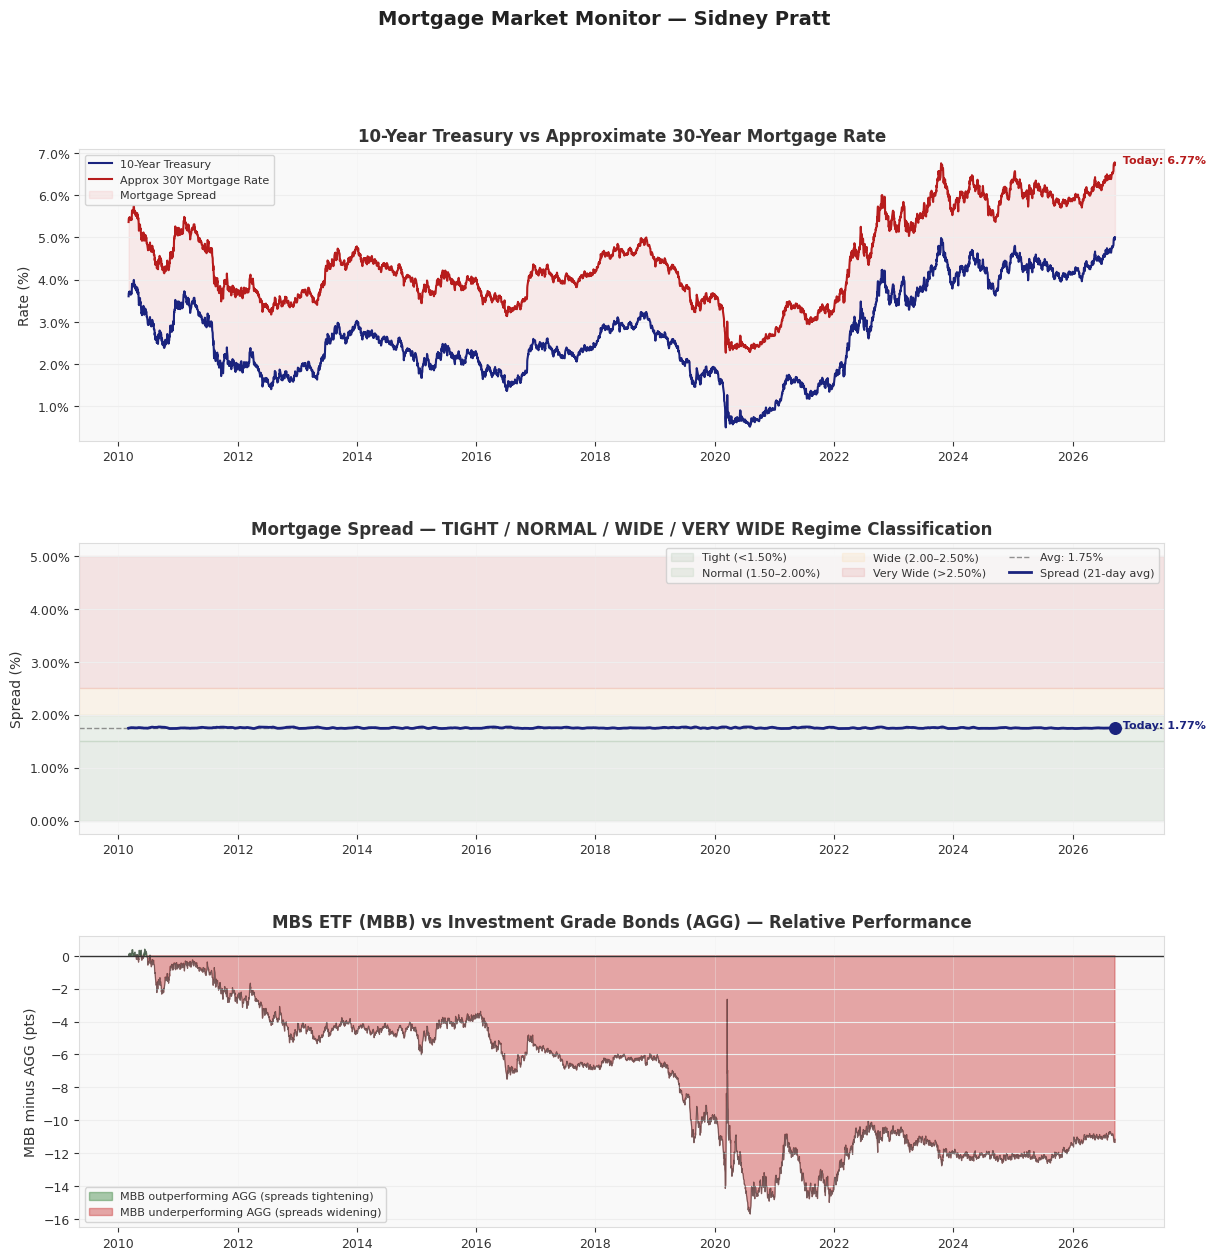

Chart saved as mortgage_monitor.png


In [ ]:
fig = plt.figure(figsize=(14, 14))
fig.patch.set_facecolor("#FFFFFF")
gs   = gridspec.GridSpec(3, 1, figure=fig, hspace=0.35)
axes = [fig.add_subplot(gs[i]) for i in range(3)]

for ax in axes:
    ax.set_facecolor("#F9F9F9")
    ax.tick_params(colors="#333333", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#DDDDDD")
    ax.grid(axis="y", color="#EEEEEE", linewidth=0.8)
    ax.grid(axis="x", color="#EEEEEE", linewidth=0.5, alpha=0.5)

fig.suptitle("Mortgage Market Monitor — Sidney Pratt",
             fontsize=14, fontweight="bold", color="#222222", y=0.98)

# Chart 1 — Rates over time
ax = axes[0]
ax.plot(df.index, df["10Y_Treasury"],
        color="#1A237E", linewidth=1.5, label="10-Year Treasury")
ax.plot(df.index, df["Mortgage_Rate_Approx"],
        color="#B71C1C", linewidth=1.5, label="Approx 30Y Mortgage Rate")
ax.fill_between(df.index, df["10Y_Treasury"], df["Mortgage_Rate_Approx"],
    color="#E53935", alpha=0.08, label="Mortgage Spread")
ax.set_title("10-Year Treasury vs Approximate 30-Year Mortgage Rate",
             color="#333333", fontsize=12, fontweight="bold")
ax.set_ylabel("Rate (%)", color="#333333")
ax.legend(facecolor="#F9F9F9", labelcolor="#333333", fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.annotate(f"  Today: {cur_mort:.2f}%",
    xy=(df.index[-1], cur_mort),
    fontsize=8, color="#B71C1C", fontweight="bold")

# Chart 2 — Mortgage spread with regime shading
ax = axes[1]
ax.axhspan(0,    1.50, color="#1B5E20", alpha=0.08, label="Tight (<1.50%)")
ax.axhspan(1.50, 2.00, color="#2E7D32", alpha=0.08, label="Normal (1.50–2.00%)")
ax.axhspan(2.00, 2.50, color="#F9A825", alpha=0.08, label="Wide (2.00–2.50%)")
ax.axhspan(2.50, 5.00, color="#C62828", alpha=0.10, label="Very Wide (>2.50%)")
ax.axhline(y=avg_spread, color="#666666", linewidth=1,
           linestyle="--", alpha=0.7, label=f"Avg: {avg_spread:.2f}%")
ax.plot(df.index, df["Mortgage_Spread"],
        color="#CCCCCC", linewidth=0.5, alpha=0.6)
ax.plot(df["Spread_Smooth"].index, df["Spread_Smooth"].values,
        color="#1A237E", linewidth=2, label="Spread (21-day avg)", zorder=4)
ax.scatter(df.index[-1], float(df["Spread_Smooth"].iloc[-1]),
           color="#1A237E", s=70, zorder=5)
ax.annotate(f"  Today: {cur_spread:.2f}%",
    xy=(df.index[-1], float(df["Spread_Smooth"].iloc[-1])),
    fontsize=8, color="#1A237E", fontweight="bold")
ax.set_title("Mortgage Spread — TIGHT / NORMAL / WIDE / VERY WIDE Regime Classification",
             color="#333333", fontsize=12, fontweight="bold")
ax.set_ylabel("Spread (%)", color="#333333")
ax.legend(facecolor="#F9F9F9", labelcolor="#333333", fontsize=8, ncol=3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}%"))

# Chart 3 — MBB vs AGG relative performance
ax = axes[2]
mbb_norm = (df["MBB"] / df["MBB"].iloc[0]) * 100
agg_norm = (df["AGG"] / df["AGG"].iloc[0]) * 100
relative  = mbb_norm - agg_norm
ax.fill_between(df.index, 0, relative,
    where=relative >= 0, color="#2E7D32", alpha=0.4,
    label="MBB outperforming AGG (spreads tightening)")
ax.fill_between(df.index, 0, relative,
    where=relative <  0, color="#C62828", alpha=0.4,
    label="MBB underperforming AGG (spreads widening)")
ax.axhline(y=0, color="#333333", linewidth=1)
ax.plot(df.index, relative, color="#333333", linewidth=0.8, alpha=0.6)
ax.set_title("MBS ETF (MBB) vs Investment Grade Bonds (AGG) — Relative Performance",
             color="#333333", fontsize=12, fontweight="bold")
ax.set_ylabel("MBB minus AGG (pts)", color="#333333")
ax.legend(facecolor="#F9F9F9", labelcolor="#333333", fontsize=8)

plt.tight_layout(pad=2.5)
plt.savefig("mortgage_monitor.png", dpi=140, bbox_inches="tight", facecolor="white")
plt.show()
print("Chart saved as mortgage_monitor.png")

In [ ]:
print("=" * 60)
print("MORTGAGE MARKET MONITOR — REPORT COMPLETE")
print("=" * 60)
print(f"Date:               {cur_date}")
print(f"10Y Treasury:       {cur_10y:.2f}%")
print(f"30Y Treasury:       {cur_30y:.2f}%")
print(f"Mortgage Rate:      {cur_mort:.2f}%")
print(f"Mortgage Spread:    {cur_spread:.2f}%  ({cur_spread*100:.0f} bps)")
print(f"Spread Regime:      {cur_regime}")
print(f"Refi Environment:   {cur_refi}")
print(f"Prepayment Risk:    {cur_prepay}")
print(f"Percentile:         {pct_rank:.0f}th since 2010")
print(f"MBB 1-Month:        {mbb_1m:+.1f}%")
print(f"MBB 12-Month:       {mbb_12m:+.1f}%")
print()
print("Next steps:")
print("1. File → Save a copy in GitHub → mortgage-market-monitor")
print("2. Download mortgage_monitor.png from the file browser")
print("3. Upload PNG to GitHub repo")
print("4. Tell me and I will add Model 4 to the Streamlit website")

MORTGAGE MARKET MONITOR — REPORT COMPLETE
Date:               September 18, 2026
10Y Treasury:       5.00%
30Y Treasury:       5.33%
Mortgage Rate:      6.77%
Mortgage Spread:    1.77%  (177 bps)
Spread Regime:      NORMAL
Refi Environment:   MINIMAL REFI
Prepayment Risk:    LOW
Percentile:         85th since 2010
MBB 1-Month:        -1.8%
MBB 12-Month:       +0.2%

Next steps:
1. File → Save a copy in GitHub → mortgage-market-monitor
2. Download mortgage_monitor.png from the file browser
3. Upload PNG to GitHub repo
4. Tell me and I will add Model 4 to the Streamlit website
